In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

## Phase 3, Lesson 1 — One-Way ANOVA

F-statistic = variation between groups / variation within groups  
A large F means the groups are far apart relative to the noise inside each group — strong evidence against H₀.

In [2]:
import numpy as np
from scipy import stats

np.random.seed(42)

# Scenario: three different fertilisers tested on crop yield (kg)
fertiliser_a = np.random.normal(loc=50, scale=8, size=30)
fertiliser_b = np.random.normal(loc=55, scale=8, size=30)
fertiliser_c = np.random.normal(loc=65, scale=8, size=30)

# --- One-way ANOVA ---
f_stat, p_val = stats.f_oneway(fertiliser_a, fertiliser_b, fertiliser_c)

print("ONE-WAY ANOVA")
print(f"  Group A mean: {fertiliser_a.mean():.2f}")
print(f"  Group B mean: {fertiliser_b.mean():.2f}")
print(f"  Group C mean: {fertiliser_c.mean():.2f}")
print(f"  F-statistic:  {f_stat:.4f}")
print(f"  p-value:      {p_val:.4f}")
print(f"  Decision: {'REJECT H₀ — at least one group differs' if p_val <= 0.05 else 'FAIL TO REJECT H₀'}")

ONE-WAY ANOVA
  Group A mean: 48.49
  Group B mean: 54.03
  Group C mean: 65.10
  F-statistic:  37.7923
  p-value:      0.0000
  Decision: REJECT H₀ — at least one group differs


In [4]:
pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ----------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\celin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np

# Stack all values into one array
all_values = np.concatenate([fertiliser_a, fertiliser_b, fertiliser_c])

# Create matching group labels
all_labels = ['A']*30 + ['B']*30 + ['C']*30

# Run Tukey
tukey = pairwise_tukeyhsd(endog=all_values, groups=all_labels, alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B   5.5359 0.0151  0.8971 10.1746   True
     A      C  16.6083    0.0 11.9695  21.247   True
     B      C  11.0724    0.0  6.4336 15.7111   True
----------------------------------------------------


## Phase 3, Lesson 2 — Correlation

In [6]:
import numpy as np
from scipy import stats

np.random.seed(42)

# Scenario: hours studied vs exam score
hours   = np.random.uniform(1, 10, size=50)
scores  = hours * 7 + np.random.normal(0, 8, size=50)
# score = 7 × hours + noise — a real linear relationship

# --- Pearson ---
r_p, p_pearson = stats.pearsonr(hours, scores)
print(f"Pearson  r = {r_p:.4f},  p = {p_pearson:.4f}")

# --- Spearman ---
r_s, p_spearman = stats.spearmanr(hours, scores)
print(f"Spearman r = {r_s:.4f},  p = {p_spearman:.4f}")

print()

# Now introduce a single extreme outlier and see what changes
hours_out  = np.append(hours, 5)
scores_out = np.append(scores, 200)   # impossible score — extreme outlier

r_p2, _ = stats.pearsonr(hours_out, scores_out)
r_s2, _ = stats.spearmanr(hours_out, scores_out)

print("After adding an extreme outlier:")
print(f"Pearson  r = {r_p2:.4f}  (changed by {r_p2 - r_p:+.4f})")
print(f"Spearman r = {r_s2:.4f}  (changed by {r_s2 - r_s:+.4f})")
print()
print("Spearman is more stable — the outlier only gets rank 'highest'")

Pearson  r = 0.9238,  p = 0.0000
Spearman r = 0.9220,  p = 0.0000

After adding an extreme outlier:
Pearson  r = 0.5854  (changed by -0.3383)
Spearman r = 0.8994  (changed by -0.0227)

Spearman is more stable — the outlier only gets rank 'highest'


## Phase 3, Lesson 3 — Simple Linear Regression

Y = slope × X + intercept

LINEAR REGRESSION RESULTS
  Slope:      6.8014
  Intercept:  0.9721
  r-value:    0.9238
  p-value:    0.0000
  std error:  0.4070

Interpretation:
  Each extra hour studied is associated with
  6.80 more marks on average.

  Predicted score for 7 hours: 48.6


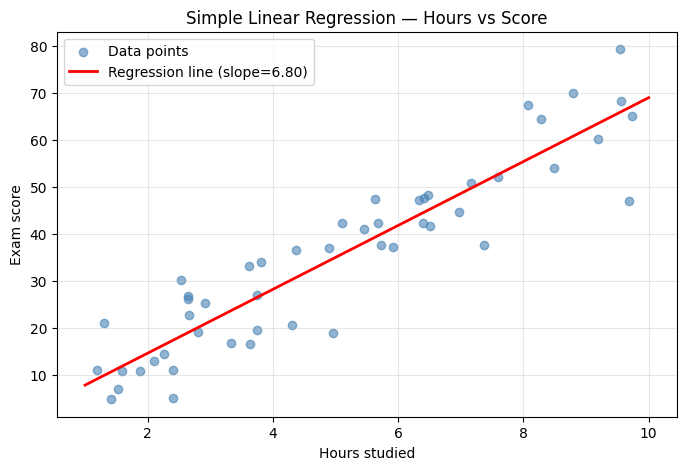

In [9]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)

# Same data: hours studied vs exam score
hours  = np.random.uniform(1, 10, size=50)
scores = hours * 7 + np.random.normal(0, 8, size=50)

# --- Fit linear regression ---
result = stats.linregress(hours, scores)

print("LINEAR REGRESSION RESULTS")
print(f"  Slope:      {result.slope:.4f}")
print(f"  Intercept:  {result.intercept:.4f}")
print(f"  r-value:    {result.rvalue:.4f}")
print(f"  p-value:    {result.pvalue:.4f}")
print(f"  std error:  {result.stderr:.4f}")
print()

# --- Interpret the slope ---
print(f"Interpretation:")
print(f"  Each extra hour studied is associated with")
print(f"  {result.slope:.2f} more marks on average.")
print()

# --- Make a prediction ---
hours_studied = 7
predicted = result.slope * hours_studied + result.intercept
print(f"  Predicted score for {hours_studied} hours: {predicted:.1f}")

# --- Plot the regression line ---
x_line = np.linspace(1, 10, 100)
y_line = result.slope * x_line + result.intercept

plt.figure(figsize=(8, 5))
plt.scatter(hours, scores, color='steelblue', alpha=0.6, label='Data points')
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Regression line (slope={result.slope:.2f})')
plt.xlabel("Hours studied")
plt.ylabel("Exam score")
plt.title("Simple Linear Regression — Hours vs Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Practical questions

In [15]:
import numpy as np
from scipy import stats

np.random.seed(1)
gym_a = np.random.normal(loc=5, scale=2, size=30)
gym_b = np.random.normal(loc=7, scale=2, size=30)
gym_c = np.random.normal(loc=7, scale=2, size=30)

# --- One-way ANOVA ---
f_stat, p_val = stats.f_oneway(gym_a, gym_b, gym_c)

print("ONE-WAY ANOVA")
print(f"  Group A mean: {gym_a.mean():.2f}")
print(f"  Group B mean: {gym_b.mean():.2f}")
print(f"  Group C mean: {gym_c.mean():.2f}")
print(f"  F-statistic:  {f_stat:.4f}")
print(f"  p-value:      {p_val:.4f}")
print(f"  Decision: {'REJECT H₀ — at least one group differs' if p_val <= 0.05 else 'FAIL TO REJECT H₀'}")

ONE-WAY ANOVA
  Group A mean: 4.88
  Group B mean: 7.15
  Group C mean: 7.33
  F-statistic:  16.3435
  p-value:      0.0000
  Decision: REJECT H₀ — at least one group differs


In [14]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np

# Stack all values into one array
all_values = np.concatenate([gym_a, gym_b, gym_c])

# Create matching group labels
all_labels = ['A']*30 + ['B']*30 + ['C']*30

# Run Tukey
tukey = pairwise_tukeyhsd(endog=all_values, groups=all_labels, alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B    2.273    0.0  1.1341 3.4119   True
     A      C   2.4473    0.0  1.3083 3.5862   True
     B      C   0.1742 0.9293 -0.9647 1.3132  False
---------------------------------------------------


Pearson  r = 0.9681,  p = 0.0000
Spearman r = 0.9493,  p = 0.0000

LINEAR REGRESSION RESULTS
  Slope:      2.9472
  Intercept:  2.5273
  r-value:    0.9681
  p-value:    0.0000
  std error:  0.1238



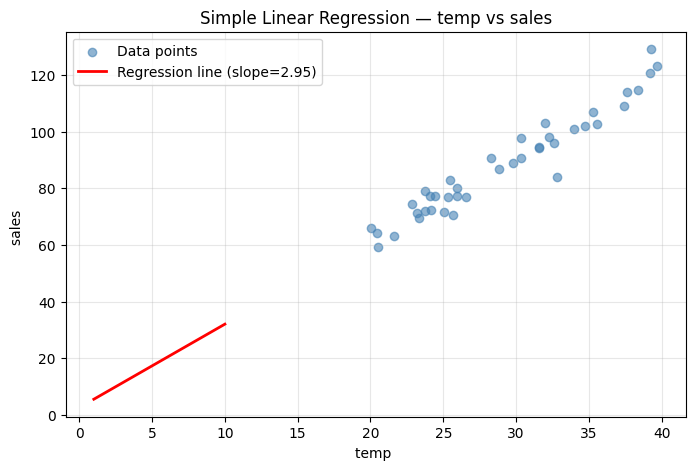

In [19]:
import numpy as np
from scipy import stats

np.random.seed(5)
temp    = np.random.uniform(20, 40, size=40)
sales   = temp * 3 + np.random.normal(0, 5, size=40)

# --- Pearson ---
r_p, p_pearson = stats.pearsonr(temp, sales)
print(f"Pearson  r = {r_p:.4f},  p = {p_pearson:.4f}")

# --- Spearman ---
r_s, p_spearman = stats.spearmanr(temp, sales)
print(f"Spearman r = {r_s:.4f},  p = {p_spearman:.4f}")

print()

result = stats.linregress(temp, sales)

print("LINEAR REGRESSION RESULTS")
print(f"  Slope:      {result.slope:.4f}")
print(f"  Intercept:  {result.intercept:.4f}")
print(f"  r-value:    {result.rvalue:.4f}")
print(f"  p-value:    {result.pvalue:.4f}")
print(f"  std error:  {result.stderr:.4f}")
print()

# --- Plot the regression line ---
x_line = np.linspace(1, 10, 100)
y_line = result.slope * x_line + result.intercept

plt.figure(figsize=(8, 5))
plt.scatter(temp, sales, color='steelblue', alpha=0.6, label='Data points')
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Regression line (slope={result.slope:.2f})')
plt.xlabel("temp ")
plt.ylabel("sales ")
plt.title("Simple Linear Regression — temp vs sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
